In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.07MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]


In [ ]:
class VAE(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Linear(784, 256),
        nn.ReLU()
    )
    self.mean = nn.Linear(256, latent_dim)
    self.variance = nn.Linear(256, latent_dim)

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 784),
        nn.Sigmoid()
    )

  def forward(self, x):
    x = self.encoder(x)
    mu = self.mean(x)
    log_var = self.variance(x)

    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(mu)
    z = mu + std * eps
    out = self.decoder(z)
    return out, mu, log_var

In [ ]:
model = VAE(latent_dim=128)

In [ ]:
loss_fn_reconstrution = nn.BCELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 100

In [ ]:
for epoch in range(num_epochs):
  model.train()
  total_loss = 0
  for batch_idx, (images, _) in enumerate(train_loader):
    images = images.view(images.size(0), -1)

    x_hat, mu, log_var = model(images)
    loss_rnt = loss_fn_reconstrution(x_hat, images) / images.size(0)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1).mean()
    loss = loss_rnt + kl

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/100], Loss: 183.2875
Epoch [2/100], Loss: 139.0408
Epoch [3/100], Loss: 126.1015
Epoch [4/100], Loss: 118.7208
Epoch [5/100], Loss: 114.7180
Epoch [6/100], Loss: 112.3443
Epoch [7/100], Loss: 110.7820
Epoch [8/100], Loss: 109.7145
Epoch [9/100], Loss: 108.8758
Epoch [10/100], Loss: 108.2424
Epoch [11/100], Loss: 107.7369
Epoch [12/100], Loss: 107.2952
Epoch [13/100], Loss: 106.9314
Epoch [14/100], Loss: 106.7043
Epoch [15/100], Loss: 106.4209
Epoch [16/100], Loss: 106.1526
Epoch [17/100], Loss: 105.9702
Epoch [18/100], Loss: 105.8042
Epoch [19/100], Loss: 105.6523
Epoch [20/100], Loss: 105.4607
Epoch [21/100], Loss: 105.3755
Epoch [22/100], Loss: 105.2758
Epoch [23/100], Loss: 105.1441
Epoch [24/100], Loss: 104.9994
Epoch [25/100], Loss: 104.9253
Epoch [26/100], Loss: 104.8135
Epoch [27/100], Loss: 104.7481
Epoch [28/100], Loss: 104.6974
Epoch [29/100], Loss: 104.5507
Epoch [30/100], Loss: 104.4632
Epoch [31/100], Loss: 104.4286
Epoch [32/100], Loss: 104.3502
Epoch [33/100], L

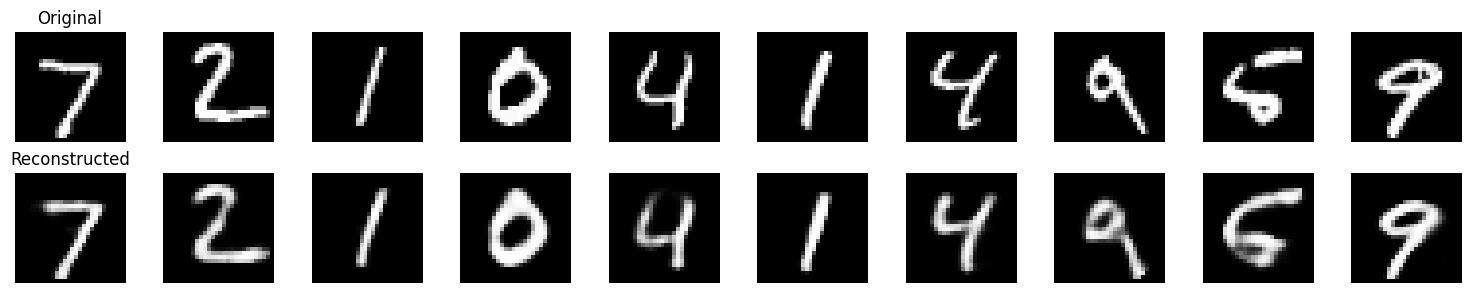

In [ ]:
model.eval()
test_images, _ = next(iter(test_loader))
test_images_flat = test_images.view(test_images.size(0), -1)

with torch.no_grad():
    x_hat, _, _ = model(test_images_flat)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_hat[i].view(28, 28).numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original')
axes[1, 0].set_title('Reconstructed')
plt.tight_layout()
plt.show()


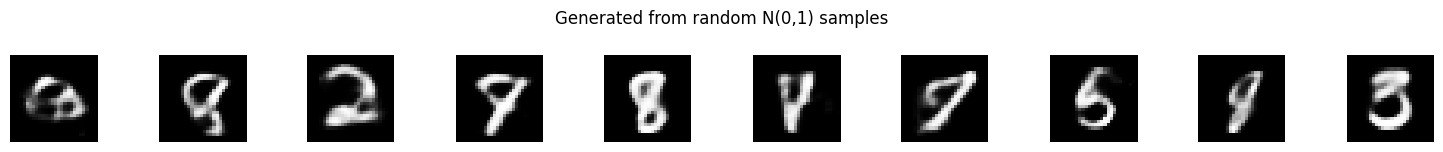

In [ ]:

with torch.no_grad():
    z = torch.randn(10, 128)
    generated = model.decoder(z)

fig, axes = plt.subplots(1, 10, figsize=(15, 1.5))
for i in range(10):
    axes[i].imshow(generated[i].view(28, 28).numpy(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('Generated from random N(0,1) samples')
plt.tight_layout()
plt.show()


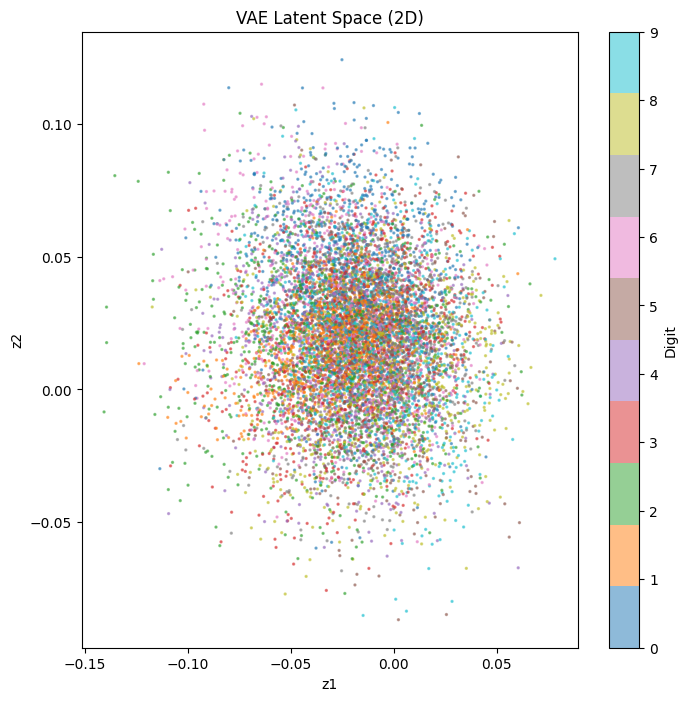

In [ ]:
all_z = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        mu = model.mean(model.encoder(images))
        all_z.append(mu)
        all_labels.append(labels)

all_z = torch.cat(all_z).numpy()
all_labels = torch.cat(all_labels).numpy()

plt.figure(figsize=(8, 8))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, label='Digit')
plt.title('VAE Latent Space (2D)')
plt.xlabel('z1')
plt.ylabel('z2')
plt.show()

In [ ]:
torch.save(model.state_dict(), 'vae_2d.pth')

In [ ]:
np.savez('vae_latent_data.npz', z=all_z, labels=all_labels)

# Convultion VAE


In [2]:
!pip install datasets -q

In [3]:
from datasets import load_dataset

ds = load_dataset("amirali900/Anime-Face-Dataset-10k", split="train")
print(len(ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/282 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

10000


In [ ]:
from datasets import load_dataset

ds = load_dataset("huggan/anime-faces", split="train")

In [4]:
print(f"Dataset size: {len(ds)}")

Dataset size: 10000


CNN VAE Model

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
class CNNVAE(nn.Module):
  def __init__(self, in_channel, out_channel, latent_dim):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(in_channel, 32, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Flatten(),
    )

    self.mu = nn.Linear(4096, latent_dim)
    self.variance = nn.Linear(4096, latent_dim)

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, 4096),
        nn.ReLU(),
        nn.Unflatten(1, (256, 4, 4)),
        nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.ConvTranspose2d(32, out_channel, kernel_size=4, stride=2, padding=1),
        nn.Sigmoid()
    )
  def forward(self, x):
    x = self.encoder(x)
    mu = self.mu(x)
    log_var = self.variance(x)
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(mu)
    z = mu + std * eps
    out = self.decoder(z)
    return out, mu, log_var

In [6]:
class AnimeDataset(torch.utils.data.Dataset):
  def __init__(self, dataset, transform):
    super().__init__()
    self.dataset = dataset
    self.transform = transform

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, index):
     image = self.dataset[index]['image'].convert('RGB')
     image = self.transform(image)
     return image

In [7]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
])

In [8]:
dataset = AnimeDataset(ds, transform)

In [9]:
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [10]:
images = next(iter(train_loader))
print(images.shape)

torch.Size([64, 3, 64, 64])


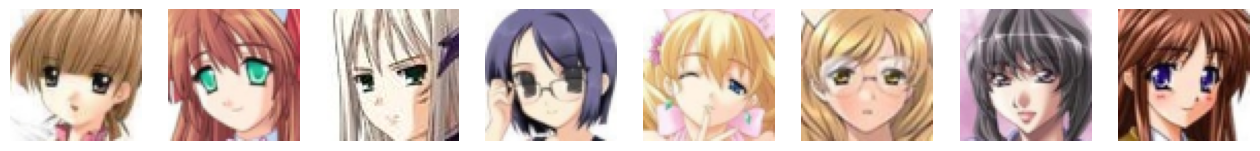

In [11]:
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
  axes[i].imshow(images[i].permute(1, 2, 0).numpy())
  axes[i].axis('off')
plt.show()

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [13]:
model = CNNVAE(in_channel=3, out_channel=3, latent_dim=128)
model.to(device)

CNNVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (mu): Linear(in_features=4096, out_features=128, bias=True)
  (variance): Linear(in_features=4096, out_features=128, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_fe

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss(reduction='sum')

In [19]:
num_epochs = 1000

In [20]:
for epoch in range(num_epochs):
  total_loss = 0
  model.train()

  for images in train_loader:
    images = images.to(device)

    x_hat, mu, log_var = model(images)
    recon_loss = loss_fn(x_hat, images) / images.size(0)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1).mean()
    loss = recon_loss + kl

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader)
  if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.2f}")

Epoch [5/1000], Loss: 6402.80
Epoch [10/1000], Loss: 6401.74
Epoch [15/1000], Loss: 6400.17
Epoch [20/1000], Loss: 6397.08
Epoch [25/1000], Loss: 6396.40
Epoch [30/1000], Loss: 6393.99
Epoch [35/1000], Loss: 6392.92
Epoch [40/1000], Loss: 6391.99
Epoch [45/1000], Loss: 6389.39
Epoch [50/1000], Loss: 6387.54
Epoch [55/1000], Loss: 6387.48
Epoch [60/1000], Loss: 6387.12
Epoch [65/1000], Loss: 6384.42
Epoch [70/1000], Loss: 6381.96
Epoch [75/1000], Loss: 6381.99
Epoch [80/1000], Loss: 6381.10
Epoch [85/1000], Loss: 6381.07
Epoch [90/1000], Loss: 6379.62
Epoch [95/1000], Loss: 6378.36
Epoch [100/1000], Loss: 6377.78
Epoch [105/1000], Loss: 6376.86
Epoch [110/1000], Loss: 6376.36
Epoch [115/1000], Loss: 6373.87
Epoch [120/1000], Loss: 6373.71
Epoch [125/1000], Loss: 6373.14
Epoch [130/1000], Loss: 6372.19
Epoch [135/1000], Loss: 6371.75
Epoch [140/1000], Loss: 6370.93
Epoch [145/1000], Loss: 6371.22
Epoch [150/1000], Loss: 6368.29
Epoch [155/1000], Loss: 6368.99
Epoch [160/1000], Loss: 6367

KeyboardInterrupt: 

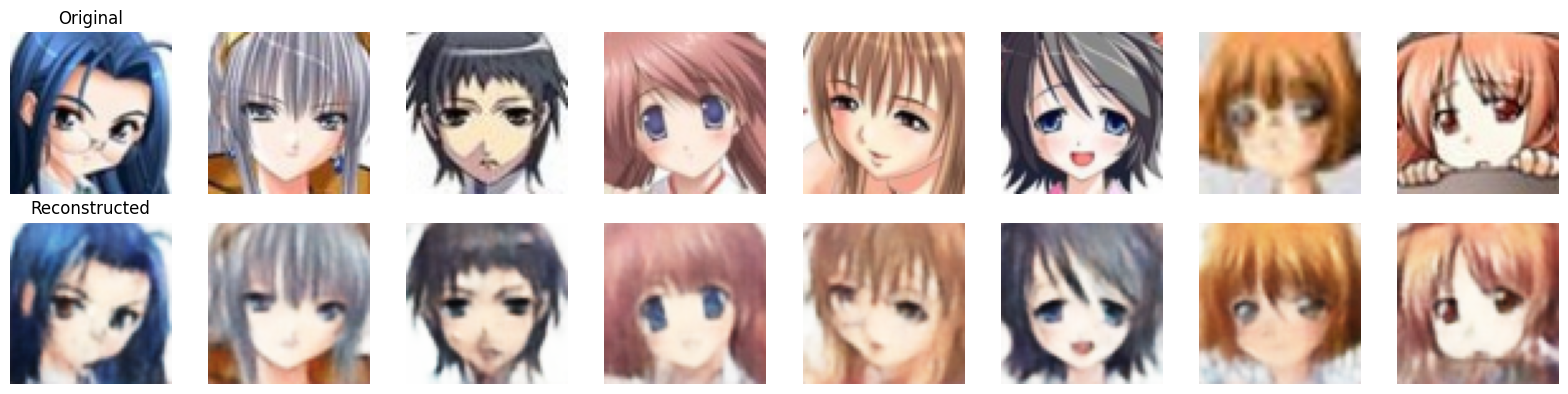

In [21]:
model.eval()
test_images = next(iter(train_loader)).to(device)

with torch.no_grad():
    x_hat, _, _ = model(test_images)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(test_images[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(x_hat[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
axes[0, 0].set_title('Original')
axes[1, 0].set_title('Reconstructed')
plt.tight_layout()
plt.show()


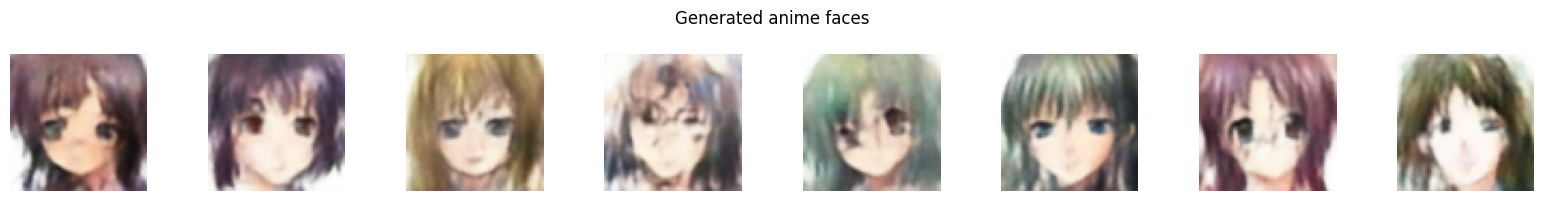

In [22]:
with torch.no_grad():
    z = torch.randn(8, 128).to(device)
    generated = model.decoder(z)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    axes[i].imshow(generated[i].cpu().permute(1, 2, 0).numpy())
    axes[i].axis('off')
plt.suptitle('Generated anime faces')
plt.tight_layout()
plt.show()


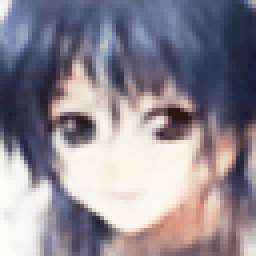

In [29]:
from IPython.display import display, Image as IPImage
import PIL.Image

model.eval()

with torch.no_grad():
    # Two random faces
    z1 = torch.randn(1, 128).to(device)
    z2 = torch.randn(1, 128).to(device)

    # 20 steps between them
    frames = []
    for i in range(20):
        alpha = i / 19
        z = (1 - alpha) * z1 + alpha * z2  # linear interpolation
        img = model.decoder(z)
        img = img.cpu().squeeze().permute(1, 2, 0).numpy()
        img = (img * 255).astype(np.uint8)
        # Scale up
        pil_img = PIL.Image.fromarray(img).resize((256, 256), PIL.Image.NEAREST)
        frames.append(pil_img)

# Save as GIF
frames[0].save(
    'anime_morph.gif',
    save_all=True,
    append_images=frames[1:],
    duration=150,
    loop=0
)

# Display
display(IPImage(filename='anime_morph.gif'))

In [27]:
torch.save(model.state_dict(), 'conv_vae_anime.pth')

# GAN

In [1]:
!pip install datasets -q

In [2]:
from datasets import load_dataset

ds = load_dataset("amirali900/Anime-Face-Dataset-10k", split="train")
print(len(ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/282 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

10000


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [5]:
class AnimeDataset(torch.utils.data.Dataset):
  def __init__(self, dataset, transform):
    super().__init__()
    self.dataset = dataset
    self.transform = transform

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, index):
     image = self.dataset[index]['image'].convert('RGB')
     image = self.transform(image)
     return image

In [6]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # scales [0,1] → [-1,1]
])

In [20]:
dataset = AnimeDataset(ds, transform)

In [21]:
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [8]:

class Generator(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()
    self.gen = nn.Sequential(
        nn.Linear(latent_dim, 256 * 4 * 4),
        nn.ReLU(),
        nn.Unflatten(1, (256, 4, 4)),
        nn.ConvTranspose2d(256, 128, 4, 2, 1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.ConvTranspose2d(128, 64, 4, 2, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, 4, 2, 1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.ConvTranspose2d(32, 3, 4, 2, 1),
        nn.Tanh()
    )
  def forward(self, x):
    x = self.gen(x)
    return x

class Discriminator(nn.Module):
  def __init__(self, in_channel, out_channel):
    super().__init__()
    self.dis = nn.Sequential(
        nn.Conv2d(in_channel, 32, 4, 2, 1),
        nn.LeakyReLU(0.2),
        nn.Conv2d(32, 64, 4, 2, 1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),
        nn.Conv2d(64, 128, 4, 2, 1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),
        nn.Conv2d(128, 256, 4, 2, 1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2),
        nn.Flatten(),
        nn.Linear((256 * 4 * 4), 1),
        nn.Sigmoid()
    )
  def forward(self, x):
    x = self.dis(x)
    return x

In [17]:
latent_dim = 128

In [18]:
generator = Generator(latent_dim=latent_dim).to(device)
discriminator = Discriminator(in_channel=3, out_channel=1).to(device)

In [13]:
num_epochs = 100

In [14]:
optim_gen = torch.optim.Adam(generator.parameters(), lr=1e-3)
optim_dis = torch.optim.Adam(discriminator.parameters(), lr=1e-3)

In [15]:
loss_fn = nn.BCELoss()

In [22]:
for epoch in range(num_epochs):
  total_loss_dis = 0
  total_loss_gen = 0
  generator.train()
  discriminator.train()

  for images in train_loader:
    images = images.to(device)
    batch_size = images.size(0)

    true_label = torch.ones(batch_size, 1).to(device)
    fake_label = torch.zeros(batch_size, 1).to(device)

    z = torch.randn(batch_size, latent_dim).to(device)
    fake_images = generator(z)

    d_real = discriminator(images)
    d_fake = discriminator(fake_images.detach())
    d_loss = loss_fn(d_real, true_label)
    d_loss += loss_fn(d_fake, fake_label)

    optim_dis.zero_grad()
    d_loss.backward()
    optim_dis.step()

    total_loss_dis += d_loss.item()

    z = torch.randn(batch_size, latent_dim).to(device)
    fake_images = generator(z)
    d_fake = discriminator(fake_images)
    g_loss = loss_fn(d_fake, true_label)

    optim_gen.zero_grad()
    g_loss.backward()
    optim_gen.step()

    total_loss_gen += g_loss.item()

  avg_loss_dis = total_loss_dis / len(train_loader)
  avg_loss_gen = total_loss_gen / len(train_loader)
  if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Discriminator Loss: {avg_loss_dis:.2f}, Generator Loss: {avg_loss_gen:.2f}")

KeyboardInterrupt: 